In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv("Tasla_Stock_Updated_V2.csv")
df.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume
0,0,2015-01-02,14.858000,14.883333,14.217333,14.620667,71466000
1,1,2015-01-05,14.303333,14.433333,13.810667,14.006000,80527500
2,2,2015-01-06,14.004000,14.280000,13.614000,14.085333,93928500
3,3,2015-01-07,14.223333,14.318667,13.985333,14.063333,44526000
4,4,2015-01-08,14.187333,14.253333,14.000667,14.041333,51637500


In [4]:
df.tail()

,Unnamed: 0,Date,Open,High,Low,Close,Volume
2269,2269,2024-01-09,238.110001,238.960007,232.039993,234.960007,96705700
2270,2270,2024-01-10,235.100006,235.500000,231.289993,233.940002,91628500
2271,2271,2024-01-11,230.570007,230.929993,225.369995,227.220001,105873600
2272,2272,2024-01-12,220.080002,225.339996,217.149994,218.889999,122889000
2273,2273,2024-01-16,215.100006,223.490005,212.180099,219.910004,115064708


In [17]:
df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df.fillna(method="ffill", inplace=True)

print(df.duplicated().sum())

0


C:\Users\moham\AppData\Local\Temp\ipykernel_7316\1310286271.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [20]:
data = df[['Close']]
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [32]:
x_train = []
y_train = []

for i in range(60, len(scaled_data)):
    x_train.append(scaled_data[i-60:i,0])
    y_train.append(scaled_data[i,0])

x_train = np.array(x_train)
y_train = np.array(y_train)

x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
print(x_train.shape,y_train.shape)

(2214, 60, 1) (2214,)


In [38]:
model = Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(64,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32))
model.add(Dense(16))
model.add(Dense(1))

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          29,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,465 (165.88 KB)

 Trainable params: 42,465 (165.88 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [45]:
callbacks = [EarlyStopping(monitor='loss',patience=10,restore_best_weights=True)]
history = model.fit(x_train,y_train,epochs=100,batch_size=32,callbacks = callbacks)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.4039e-04
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 7.4428e-04
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 8.4624e-04
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 7.7316e-04
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.6588e-04
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.5565e-04
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 7.9032e-04
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 8.0039e-04
Epoch 9/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.1950e-04
Epoch 10/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 6.9563e-04
Epoch 11/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 7.7068e-04
Epoch 12/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 7.2982e-04
Epoch 13/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 8.0523e-04
Epoch 14/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.5278e-04
E

In [46]:
test_size = int(len(scaled_data)*0.2)
train_data = scaled_data[:-test_size]
test_data = scaled_data[-(test_size+60):]

In [47]:
x_test=[]
y_test=[]
for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i,0])
    y_test.append(test_data[i,0])

x_test=np.array(x_test)
y_test=np.array(y_test)
x_test=np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

In [48]:
predictions=model.predict(x_test)
predictions=scaler.inverse_transform(predictions)
y_actual=scaler.inverse_transform(y_test.reshape(-1,1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [49]:
mae=mean_absolute_error(y_actual,predictions)
print("MAE:",mae)

mse=mean_squared_error(y_actual,predictions)
print("MSE:",mse)

rmse=np.sqrt(mse)
print("RMSE:",rmse)

MAE: 8.321576391547786
MSE: 113.84802915000932
RMSE: 10.669959191581256


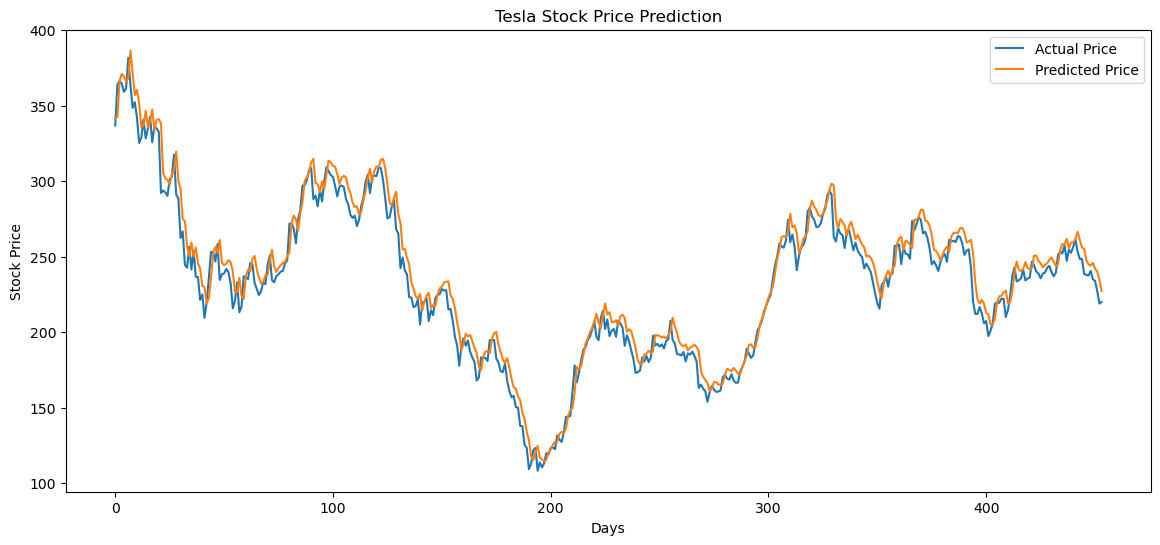

In [50]:
plt.figure(figsize=(14,6))
plt.plot(y_actual,label='Actual Price')
plt.plot(predictions,label='Predicted Price')
plt.title("Tesla Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [51]:
last_60 = scaled_data[-60:]
X_future = np.array([last_60])
prediction = model.predict(X_future)
prediction = scaler.inverse_transform(prediction)
print("Next Day Predicted Close Price:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Next Day Predicted Close Price: 225.74754
